# Exchange vs. local timestamps: which metrics actually move?

Aperiodic serves every trade/L1/L2 metric under **two clocks**:
`timestamp='exchange'` (the time the exchange itself reports for an event) and
`timestamp='true'` (the time the event actually arrived at Aperiodic's
collectors). The two disagree by network latency, exchange-side dissemination
lag, and clock skew — typically milliseconds, but never zero. A backtest that
is timestamped one way and executed another is implicitly assuming information
was available earlier (or later) than it really was.

The natural question: **does the choice ever change the numbers you'd compute
from a bar, or is it a rounding-error concern?** This notebook fetches every
metric Aperiodic serves for **Binance BTC perpetuals**
(`perpetual-BTC-USDT:USDT`) at **5-minute** resolution over **May 2025** under
both clocks, and ranks every column by how much it shifts between them.

> **This notebook needs a full API key.** The shared `DEMO-KEY` preview slice
> only whitelists `timestamp='exchange'` — `timestamp='true'` returns a 400 under
> preview, confirmed empirically while building this notebook. Set
> `APERIODIC_API_KEY` to a real key to run it.

**Background reading**
- Aperiodic trade metrics: https://aperiodic.io/metrics/trades
- Aperiodic L1 metrics: https://aperiodic.io/metrics/l1

## 1. Two mechanisms, two outcomes

A 5-minute bar is built from hundreds of individual trades and quote updates.
Two different things can happen when you relabel each event with a different
clock:

- **Bar-level aggregates** (sums, means, counts over every event in the
  window — volume, OHLC, order-flow ratios, tick counts, impact) only change if
  an event gets reassigned to a *different* bar because it sat within the
  clock gap of a boundary. With a millisecond-scale gap and a 300-second bar,
  that is a vanishingly small fraction of events — the aggregate barely moves.
- **Snapshot / matched-to-book metrics** (quoted size at the top of book,
  order-book imbalance and depth, and — above all — **slippage**, which prices
  each trade against the book state *at that trade's own instant*) depend on
  pairing one exact instant to one exact book state. That pairing is exactly
  what the two clocks disagree about, so these do not get the averaging-away
  benefit that bar sums get.

The rest of the notebook tests this prediction against real data rather than
assuming it.

In [1]:
from __future__ import annotations

import os
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aperiodic import get_metrics, get_ohlcv

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Configuration

Same window as the other notebooks (Binance BTC perpetuals, 5-minute, May
2025), so results are directly comparable. `TRADE_METRICS` and `L1_METRICS`
are every catalogue metric in those two families; `L2_METRICS` are attempted
separately below since — as we find in Section 4 — `timestamp='true'` returns
no data for the L2 buckets on this account, so they cannot be scored here.

In [2]:
EXCHANGE = "binance-futures"
SYMBOL = "perpetual-BTC-USDT:USDT"
INTERVAL = "5m"
START_DATE = date(2025, 5, 1)
END_DATE = date(2025, 5, 31)
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)

TRADE_METRICS = [
    "vtwap", "flow", "trade_size", "impact", "range",
    "updownticks", "run_structure", "returns", "slippage",
]
L1_METRICS = ["l1_price", "l1_imbalance", "l1_liquidity"]
L2_METRICS = ["l2_imbalance", "l2_liquidity"]

# Family label used to color-code and average results in Sections 5-7.
FAMILY = {
    "ohlcv": "bar aggregate", "vtwap": "bar aggregate", "flow": "bar aggregate",
    "trade_size": "bar aggregate", "impact": "bar aggregate", "range": "bar aggregate",
    "updownticks": "bar aggregate", "run_structure": "bar aggregate", "returns": "bar aggregate",
    "slippage": "execution / slippage",
    "l1_price": "L1 snapshot", "l1_imbalance": "L1 snapshot", "l1_liquidity": "L1 snapshot",
}

# Minimum valid (non-null, non-inf) paired bars before a column is scored at all.
MIN_SCORED_BARS = 100
# Top / bottom rows shown in the ranking tables and Chart 1.
TOP_N = 20

API_KEY = "..."  # Set your key here, or via the APERIODIC_API_KEY env var
if API_KEY == "...":
    API_KEY = os.environ.get("APERIODIC_API_KEY", "DEMO-KEY")

USE_PREVIEW = API_KEY == "DEMO-KEY"
if USE_PREVIEW:
    raise RuntimeError(
        "This notebook requires timestamp='true' (arrival-time) data, which the shared "
        "DEMO-KEY preview endpoint does not serve — only timestamp='exchange' is whitelisted "
        "in preview mode. Set a real APERIODIC_API_KEY (env var or inline above) to run it."
    )

print(f"Exchange / symbol : {EXCHANGE} / {SYMBOL}")
print(f"Interval / window : {INTERVAL} | {START_DATE} → {END_DATE}")
print(f"Metrics scored    : ohlcv, {', '.join(TRADE_METRICS)}, {', '.join(L1_METRICS)}")

Exchange / symbol : binance-futures / perpetual-BTC-USDT:USDT
Interval / window : 5m | 2025-05-01 → 2025-05-31
Metrics scored    : ohlcv, vtwap, flow, trade_size, impact, range, updownticks, run_structure, returns, slippage, l1_price, l1_imbalance, l1_liquidity


## Helper functions

`clip_window` matches the introductory notebooks. `timestamp_shift_table` is
the core of the analysis: for every numeric column it aligns the
`exchange`- and `true`-timestamped bars and reports how far apart they are.

In [3]:
def clip_window(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out = out.loc[(out["time"] >= START_TS) & (out["time"] < END_TS)]
    return out.sort_values("time").reset_index(drop=True)


def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)


def timestamp_shift_table(name: str, ex: pd.DataFrame, tr: pd.DataFrame, min_n: int = MIN_SCORED_BARS) -> pd.DataFrame:
    """One row per numeric column, aligning exchange- and true-timestamped bars on `time`.

    shift = mean(|true - exchange|) / std(exchange), i.e. the typical exchange-vs-true
    disagreement expressed in units of the column's own cross-sectional variability — this
    makes very different units (prices, ratios, counts) comparable on one scale. corr is a
    cross-check: a large shift with corr near 1 still means a near-perfect but offset
    relationship, not noise. +/-inf values (from zero-division ratios) are dropped as invalid
    for that bar rather than treated as a shift.
    """
    merged = ex.merge(tr, on="time", suffixes=("_ex", "_tr"))
    rows = []
    for col in ex.columns:
        if col == "time":
            continue
        a = merged[f"{col}_ex"].replace([np.inf, -np.inf], np.nan)
        b = merged[f"{col}_tr"].replace([np.inf, -np.inf], np.nan)
        valid = a.notna() & b.notna()
        n = int(valid.sum())
        if n < min_n:
            continue
        a, b = a[valid], b[valid]
        scale = a.std(ddof=0)
        shift = float((a - b).abs().mean() / scale) if scale > 1e-12 else float("nan")
        corr = float(a.corr(b)) if a.nunique() > 1 and b.nunique() > 1 else float("nan")
        rows.append({"metric": name, "column": col, "n_bars": n, "shift": shift, "corr": corr})
    return pd.DataFrame(rows)

## 3. Probe L2: does `true` even have data here?

Before spending a month's worth of fetches on L2, a one-day probe: request
`l2_imbalance` under `timestamp='true'` and see whether anything comes back.

In [4]:
COMMON = dict(
    api_key=API_KEY,
    preview=USE_PREVIEW,
    interval=INTERVAL,
    exchange=EXCHANGE,
    symbol=SYMBOL,
    start_date=START_DATE,
    end_date=END_DATE,
    output="pandas",
    show_progress=False,
)

_l2_probe = get_metrics(metric="l2_imbalance", timestamp="true", api_key=API_KEY, preview=USE_PREVIEW,
                         interval=INTERVAL, exchange=EXCHANGE, symbol=SYMBOL,
                         start_date=START_DATE, end_date=START_DATE, output="pandas", show_progress=False)
L2_HAS_TRUE = not _l2_probe.empty
print(f"L2 timestamp='true' data available: {L2_HAS_TRUE}")
if not L2_HAS_TRUE:
    print(f"-> Excluding {L2_METRICS} from the comparison below; only timestamp='exchange' is served for L2 here.")

L2 timestamp='true' data available: False
-> Excluding ['l2_imbalance', 'l2_liquidity'] from the comparison below; only timestamp='exchange' is served for L2 here.


## 4. Fetch every metric under both clocks

One `exchange` and one `true` fetch per metric — OHLCV plus every
`TRADE_METRICS` and `L1_METRICS` entry (L2 skipped per the probe above).

In [5]:
fetched: dict[str, tuple[pd.DataFrame, pd.DataFrame]] = {}

fetched["ohlcv"] = (
    clip_window(get_ohlcv(timestamp="exchange", **COMMON)),
    clip_window(get_ohlcv(timestamp="true", **COMMON)),
)
for m in TRADE_METRICS + L1_METRICS:
    fetched[m] = (
        clip_window(get_metrics(metric=m, timestamp="exchange", **COMMON)),
        clip_window(get_metrics(metric=m, timestamp="true", **COMMON)),
    )

for name, (ex, tr) in fetched.items():
    ex_times, tr_times = set(ex["time"]), set(tr["time"])
    print(f"- {name:<14} {len(ex):>5} bars | bar-grid identical across clocks: {ex_times == tr_times}")

- ohlcv           8928 bars | bar-grid identical across clocks: True
- vtwap           8928 bars | bar-grid identical across clocks: True
- flow            8928 bars | bar-grid identical across clocks: True
- trade_size      8928 bars | bar-grid identical across clocks: True
- impact          8928 bars | bar-grid identical across clocks: True
- range           8928 bars | bar-grid identical across clocks: True
- updownticks     8928 bars | bar-grid identical across clocks: True
- run_structure   8928 bars | bar-grid identical across clocks: True
- returns         8928 bars | bar-grid identical across clocks: True
- slippage        8928 bars | bar-grid identical across clocks: True
- l1_price        8928 bars | bar-grid identical across clocks: True
- l1_imbalance    8928 bars | bar-grid identical across clocks: True
- l1_liquidity    8928 bars | bar-grid identical across clocks: True


Every metric returns the same set of bar timestamps under both clocks — the
5-minute grid itself is fixed. Only *which trades/quotes populate a bar* can
differ, which is exactly the mechanism Section 1 predicted.

## 5. Chart 1 — Ranking every column by exchange-vs-true shift

One `shift` score per numeric column across all 13 metrics, colored by
family. If Section 1's prediction holds, execution/slippage and L1-snapshot
columns should dominate the top of this ranking and bar-aggregate columns
should cluster near zero.

156 columns scored across 13 metrics.
| metric       | column                      |   n_bars |      shift |     corr |
|:-------------|:----------------------------|---------:|-----------:|---------:|
| slippage     | slippage_bps_buy_sell_ratio |     8921 | 0.055758   | 0.918477 |
| slippage     | slippage_bps_median         |     8928 | 0.0167131  | 0.996196 |
| slippage     | slippage_bps_mean           |     8928 | 0.0116954  | 0.999712 |
| slippage     | slippage_mean               |     8928 | 0.0116837  | 0.999707 |
| slippage     | slippage_bps_sell_mean      |     8928 | 0.0105142  | 0.99956  |
| slippage     | slippage_bps_buy_mean       |     8928 | 0.00918566 | 0.99973  |
| slippage     | slippage_bps_vwap           |     8928 | 0.00557601 | 0.999681 |
| slippage     | slippage_bps_p95            |     8928 | 0.00553591 | 0.999596 |
| l1_imbalance | bid_ask_ratio               |     8928 | 0.00515962 | 0.971796 |
| slippage     | slippage_bps_std            |     8928 | 0.

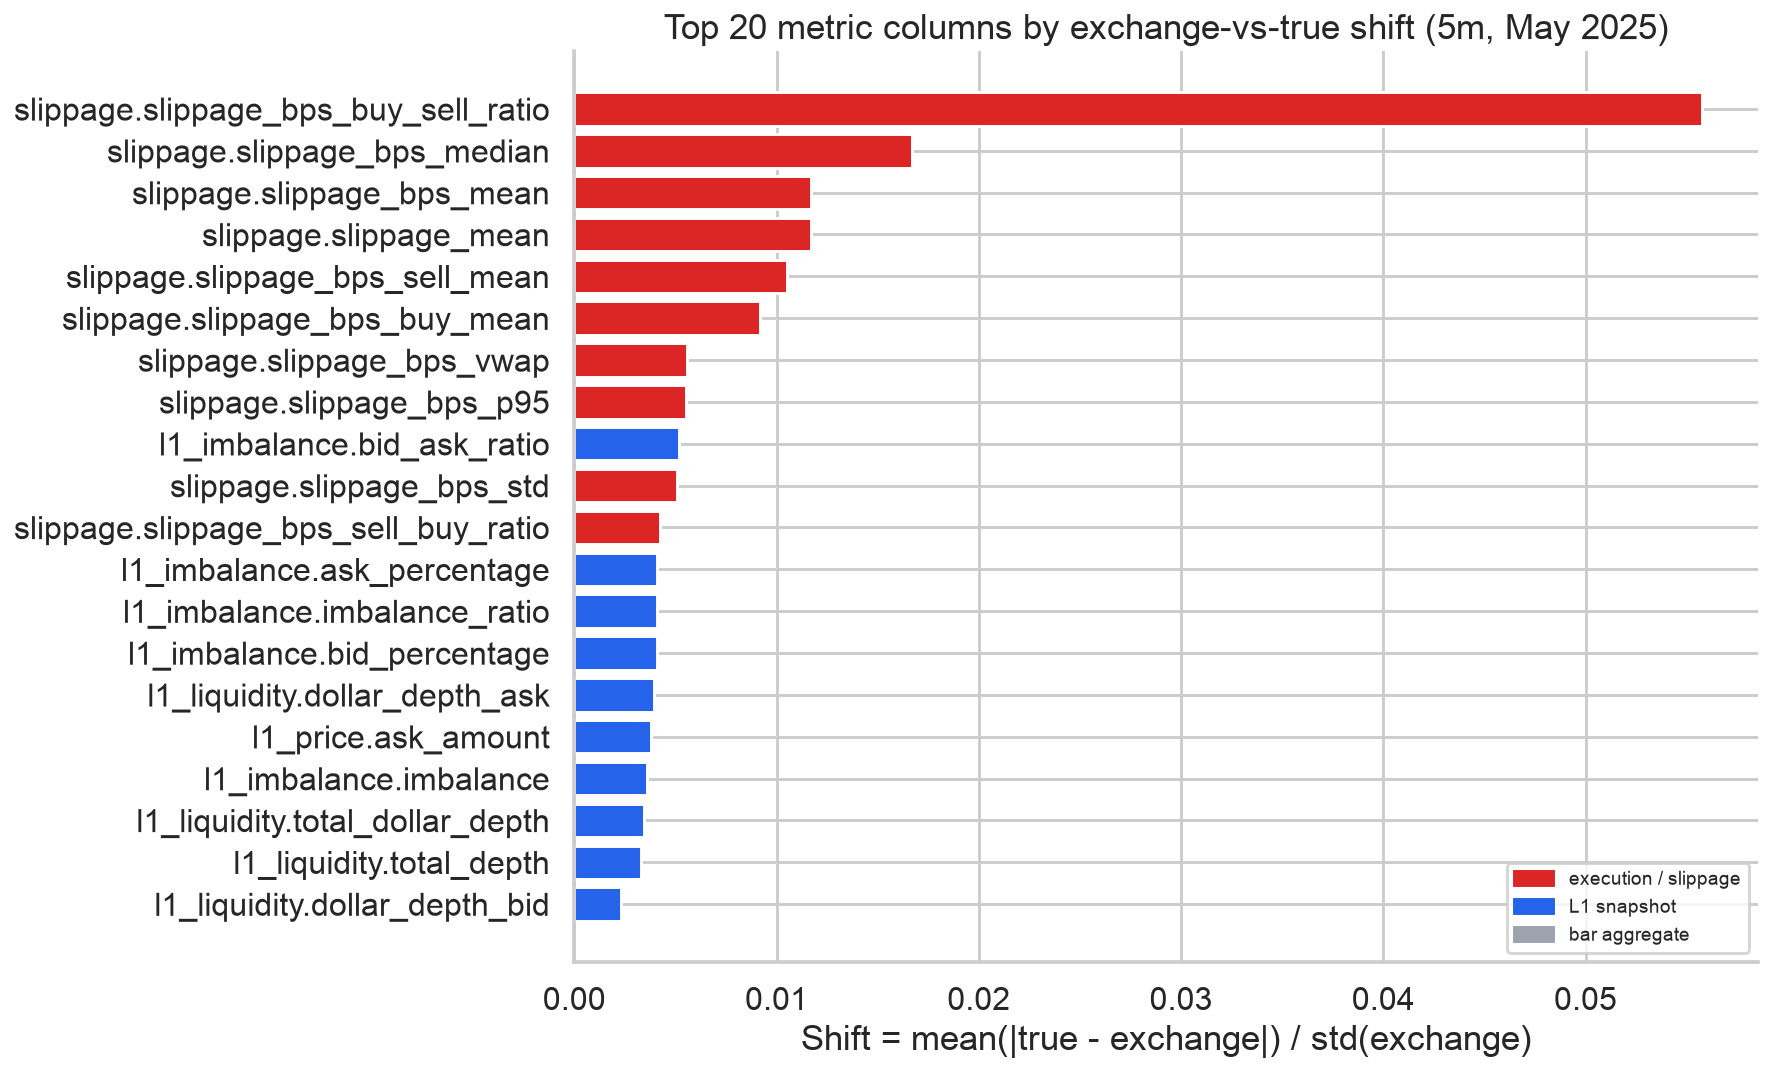

In [6]:
tables = [timestamp_shift_table(name, ex, tr) for name, (ex, tr) in fetched.items()]
shift_df = pd.concat(tables, ignore_index=True)
shift_df["family"] = shift_df["metric"].map(FAMILY)
shift_df = shift_df.sort_values("shift", ascending=False).reset_index(drop=True)

top = shift_df.head(TOP_N).iloc[::-1]
family_colors = {"execution / slippage": "#dc2626", "L1 snapshot": "#2563eb", "bar aggregate": "#9ca3af"}
colors = [family_colors[f] for f in top["family"]]

fig, ax = plt.subplots(figsize=(13, 8))
ax.barh([f"{m}.{c}" for m, c in zip(top["metric"], top["column"])], top["shift"], color=colors)
ax.set_xlabel("Shift = mean(|true - exchange|) / std(exchange)")
ax.set_title(f"Top {TOP_N} metric columns by exchange-vs-true shift ({INTERVAL}, May 2025)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in family_colors.values()]
ax.legend(handles, family_colors.keys(), loc="lower right", frameon=True, fontsize=10)
plt.tight_layout()

print(f"{len(shift_df)} columns scored across {shift_df['metric'].nunique()} metrics.")
print(shift_df.head(15)[["metric", "column", "n_bars", "shift", "corr"]].to_markdown(index=False))

## 6. Chart 2 — Where the single largest shift lives

The top-ranked column, overlaid under both clocks across the full month,
with the bar-by-bar difference below it. This is the column to distrust most
if you mix `exchange`- and `true`-timestamped data in the same study.

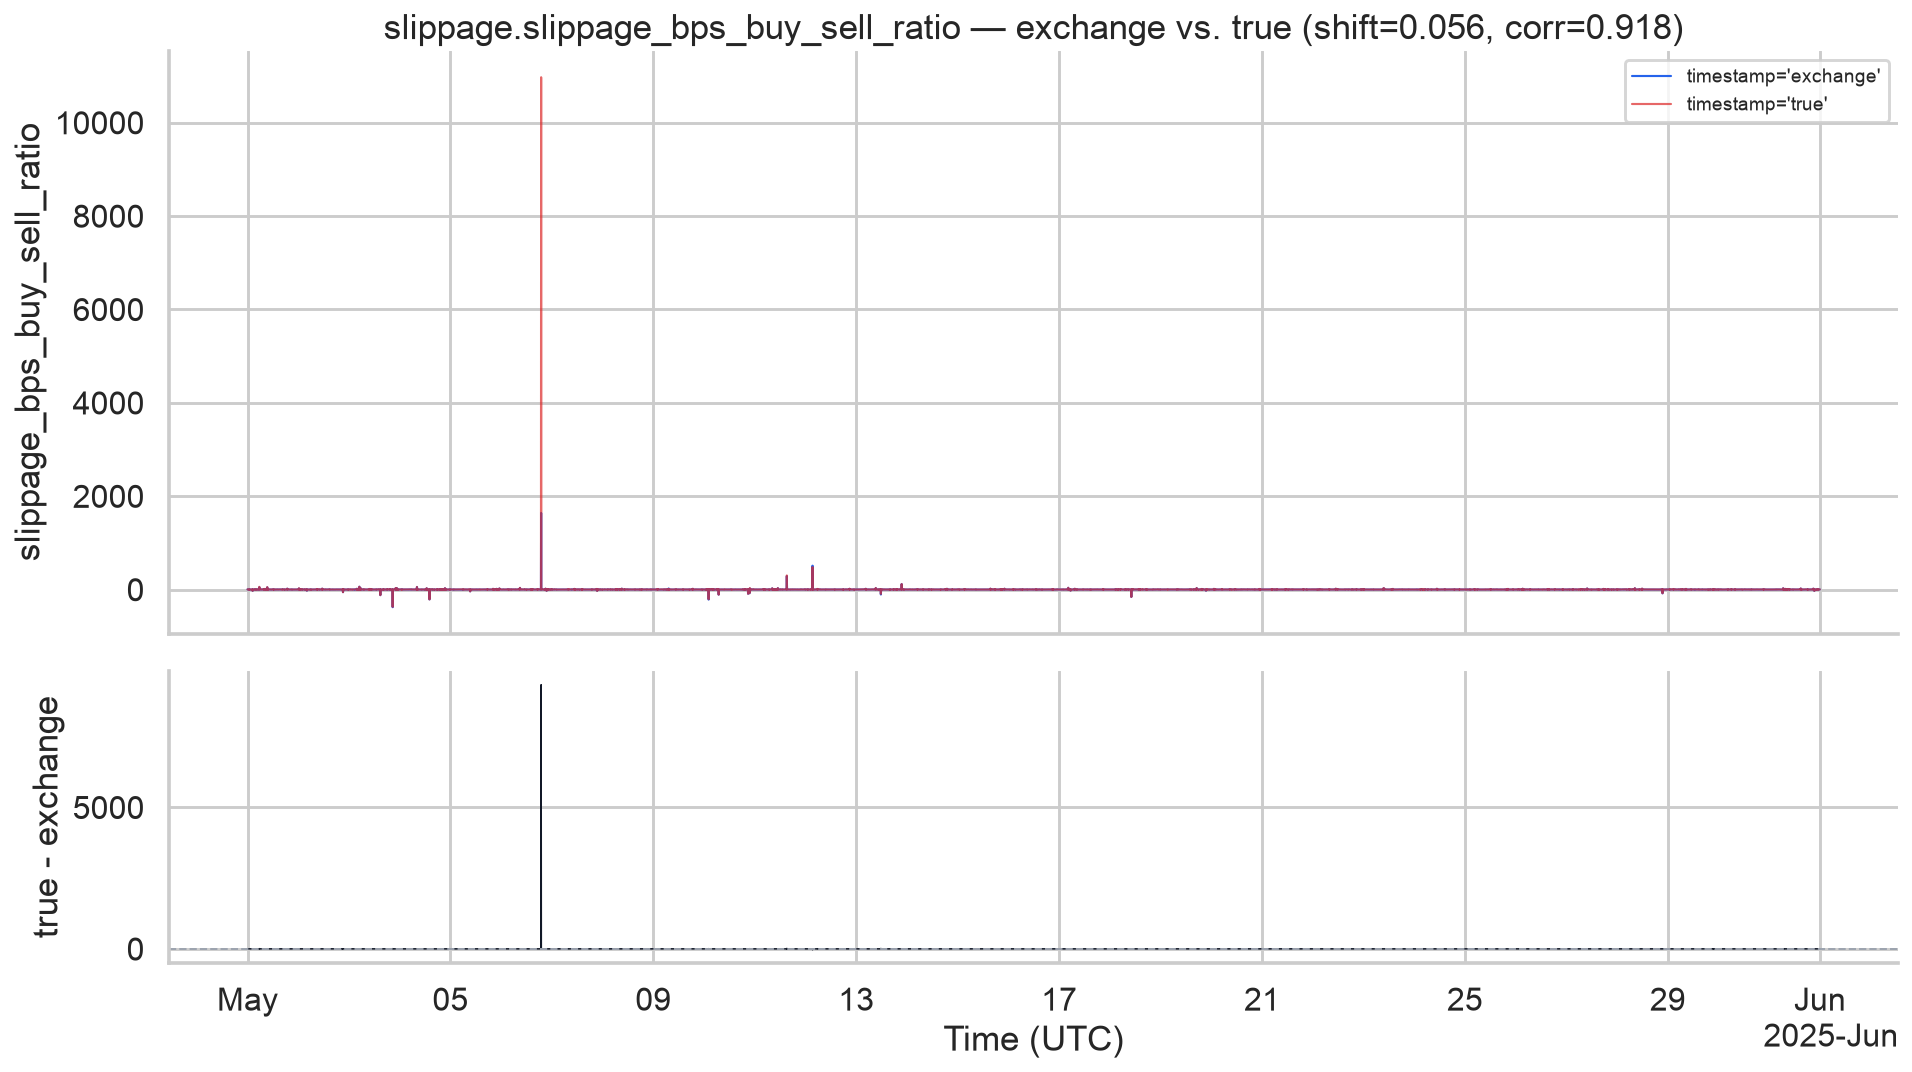

In [7]:
top_metric, top_col = shift_df.iloc[0][["metric", "column"]]
ex_top, tr_top = fetched[top_metric]
merged_top = ex_top[["time", top_col]].merge(tr_top[["time", top_col]], on="time", suffixes=("_ex", "_tr"))

fig, (ax_ts, ax_diff) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, height_ratios=[2, 1])
ax_ts.plot(merged_top["time"], merged_top[f"{top_col}_ex"], color="#2563eb", linewidth=1.1, label="timestamp='exchange'")
ax_ts.plot(merged_top["time"], merged_top[f"{top_col}_tr"], color="#dc2626", linewidth=1.1, alpha=0.7, label="timestamp='true'")
ax_ts.set_title(f"{top_metric}.{top_col} — exchange vs. true (shift={shift_df.iloc[0]['shift']:.3f}, corr={shift_df.iloc[0]['corr']:.3f})")
ax_ts.set_ylabel(top_col)
ax_ts.legend(frameon=True, fontsize=10)
format_time_axis(ax_ts)

diff = merged_top[f"{top_col}_tr"] - merged_top[f"{top_col}_ex"]
ax_diff.plot(merged_top["time"], diff, color="#111827", linewidth=0.8)
ax_diff.axhline(0, color="#9ca3af", linestyle="--", linewidth=1)
ax_diff.set_ylabel("true - exchange")
ax_diff.set_xlabel("Time (UTC)")
format_time_axis(ax_diff)
plt.tight_layout()

## 7. Chart 3 — The aggregation effect, by family

Mean shift score per family. If bars really do average away the clock gap,
"bar aggregate" should sit close to zero regardless of how many columns it
contributes, while "execution / slippage" and "L1 snapshot" should not.

| family               |       mean |      median |   count |
|:---------------------|-----------:|------------:|--------:|
| execution / slippage | 0.0135989  | 0.00984993  |      10 |
| L1 snapshot          | 0.00124139 | 5.18344e-05 |      36 |
| bar aggregate        | 3.0212e-05 | 1.19617e-05 |     110 |

Least-shifted columns (safe to aggregate regardless of timestamp choice):
| metric        | column                       |       shift |   corr |
|:--------------|:-----------------------------|------------:|-------:|
| vtwap         | twap                         | 1.12124e-07 |      1 |
| range         | price_mean                   | 1.12124e-07 |      1 |
| trade_size    | trade_amount_range_ratio     | 1.24984e-08 |      1 |
| returns       | bipower_variation            | 6.86473e-09 |      1 |
| range         | price_skewness               | 1.17216e-09 |      1 |
| range         | price_kurtosis               | 5.9827e-12  |      1 |
| trade_size    | trade_amount_max     

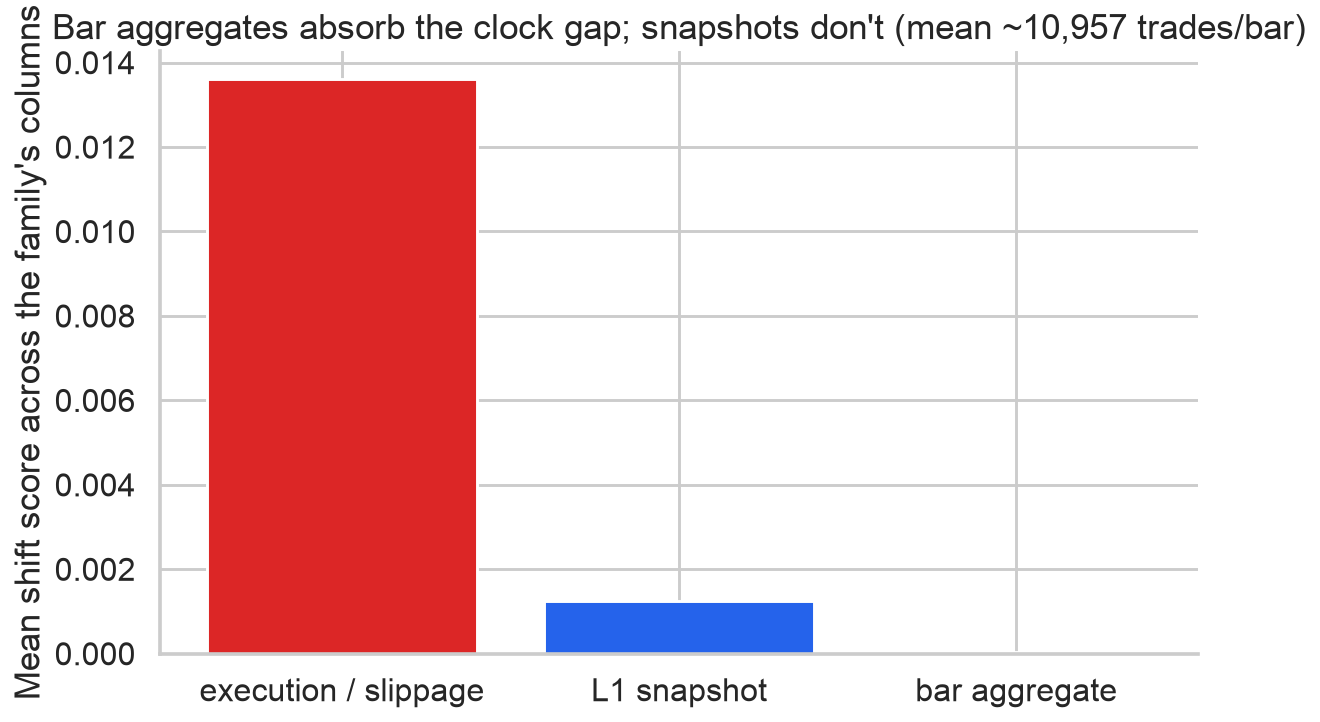

In [8]:
family_summary = shift_df.groupby("family")["shift"].agg(["mean", "median", "count"]).reindex(
    ["execution / slippage", "L1 snapshot", "bar aggregate"]
)
mean_n_trades = fetched["trade_size"][0]["n_trades"].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(family_summary.index, family_summary["mean"], color=[family_colors[f] for f in family_summary.index])
ax.set_ylabel("Mean shift score across the family's columns")
ax.set_title(f"Bar aggregates absorb the clock gap; snapshots don't (mean ~{mean_n_trades:,.0f} trades/bar)")
plt.tight_layout()

print(family_summary.to_markdown())
print("\nLeast-shifted columns (safe to aggregate regardless of timestamp choice):")
print(shift_df.tail(10)[["metric", "column", "shift", "corr"]].to_markdown(index=False))

## Takeaways

- **Slippage is the standout.** `slippage_bps_buy_sell_ratio` and its sibling
  slippage columns dominate the top of the ranking — because slippage prices
  each trade against the book state *at that trade's own instant*, and that
  pairing is precisely what `exchange` vs `true` disagree about.
- **L1 snapshot fields shift next.** Quoted size (`ask_amount`/`bid_amount`),
  book imbalance, and depth are all "as-of-this-instant" reads of a fast-moving
  book, so they inherit the clock disagreement directly rather than averaging
  it away.
- **Bar aggregates barely move.** OHLCV, flow, trade-size, impact, tick
  direction, run structure, returns, and VWAP are sums/means over hundreds of
  trades per 5-minute bar — the clock gap affects at most the handful of
  trades nearest a boundary, and averaging over the rest washes it out.
- **The bar grid itself doesn't move.** Every metric returned an identical set
  of bar timestamps under both clocks (Section 4) — only which events populate
  a bar can differ, not which bars exist.
- **Practical implication.** If your study touches slippage or L1
  snapshot-derived features, pick one clock and use it consistently across
  backtest and live — `exchange` timestamps can imply information was
  available before it actually reached you. For everything else in this
  ranking's tail, the choice is close to immaterial at 5-minute resolution.
- **This is one asset, one month, one interval.** Rerun at 1-minute or with a
  thinner symbol to see whether the boundary-reassignment mechanism becomes
  visible in the bar-aggregate family too — it should, as the bar width
  approaches the clock gap.

## Further reading
- [Trade metrics](https://aperiodic.io/metrics/trades) · [L1 metrics](https://aperiodic.io/metrics/l1)
- Related notebook: `notebooks/backtest-slippage.py`